In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
hunger_index_df=pd.read_csv(r'C:\Users\kottu\Desktop\UNICUS\PYTHON\DATA\Kaggle\global hunger index data\global-hunger-index.csv')
hunger_index_df.head()

,Entity,Code,Year,Global Hunger Index (2021),411773-annotations
0,Afghanistan,AFG,2000,50.9,NaN
1,Afghanistan,AFG,2006,42.7,NaN
2,Afghanistan,AFG,2012,34.3,NaN
3,Afghanistan,AFG,2021,28.3,NaN
4,Albania,ALB,2000,20.7,NaN


In [3]:
unemployment_df=pd.read_csv(r'C:\Users\kottu\Desktop\UNICUS\PYTHON\DATA\Kaggle\unemployment data\unemployment analysis.csv')
unemployment_df.head()

,Country Name,Country Code,1991,1992,1993,1994,1995,1996,1997,1998,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Africa Eastern and Southern,AFE,7.80,7.84,7.85,7.84,7.83,7.84,7.86,7.81,...,6.56,6.45,6.41,6.49,6.61,6.71,6.73,6.91,7.56,8.11
1,Afghanistan,AFG,10.65,10.82,10.72,10.73,11.18,10.96,10.78,10.80,...,11.34,11.19,11.14,11.13,11.16,11.18,11.15,11.22,11.71,13.28
2,Africa Western and Central,AFW,4.42,4.53,4.55,4.54,4.53,4.57,4.60,4.66,...,4.64,4.41,4.69,4.63,5.57,6.02,6.04,6.06,6.77,6.84
3,Angola,AGO,4.21,4.21,4.23,4.16,4.11,4.10,4.09,4.07,...,7.35,7.37,7.37,7.39,7.41,7.41,7.42,7.42,8.33,8.53
4,Albania,ALB,10.31,30.01,25.26,20.84,14.61,13.93,16.88,20.05,...,13.38,15.87,18.05,17.19,15.42,13.62,12.30,11.47,13.33,11.82


In [4]:
hunger_index_df.columns

Index(['Entity', 'Code', 'Year', 'Global Hunger Index (2021)',
       '411773-annotations'],
      dtype='object')

In [5]:
unemployment_df.columns

Index(['Country Name', 'Country Code', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021'],
      dtype='object')

In [6]:
a=hunger_index_df['Year'].unique()
a

array([2000, 2006, 2012, 2021])

In [7]:
hunger_index_df.drop('411773-annotations',axis=1,inplace=True)

In [8]:
selected_columns = ['Country Name', 'Country Code', '2000', '2006', '2012', '2021']
df=unemployment_df[selected_columns]

In [9]:
hunger_index_df.head()

,Entity,Code,Year,Global Hunger Index (2021)
0,Afghanistan,AFG,2000,50.9
1,Afghanistan,AFG,2006,42.7
2,Afghanistan,AFG,2012,34.3
3,Afghanistan,AFG,2021,28.3
4,Albania,ALB,2000,20.7


In [10]:
df_long = pd.melt(
    df,
    id_vars=['Country Name', 'Country Code'],
    var_name='Year',
    value_name='Indicator Value'
)

In [11]:
df_long

,Country Name,Country Code,Year,Indicator Value
0,Africa Eastern and Southern,AFE,2000,7.72
1,Afghanistan,AFG,2000,10.81
2,Africa Western and Central,AFW,2000,4.92
3,Angola,AGO,2000,4.03
4,Albania,ALB,2000,19.03
...,...,...,...,...
935,Samoa,WSM,2021,9.84
936,"Yemen, Rep.",YEM,2021,13.57
937,South Africa,ZAF,2021,33.56
938,Zambia,ZMB,2021,13.03


In [ ]:
df_long['Year'] = df_long['Year'].astype(int)

merged_df = pd.merge(
    hunger_index_df,
    df_long,
    left_on=['Code', 'Year'],
    right_on=['Country Code', 'Year'],
    how='inner' 
)
merged_df

,Entity,Code,Year,Global Hunger Index (2021),Country Name,Country Code,Indicator Value
0,Afghanistan,AFG,2000,50.9,Afghanistan,AFG,10.81
1,Afghanistan,AFG,2006,42.7,Afghanistan,AFG,11.10
2,Afghanistan,AFG,2012,34.3,Afghanistan,AFG,11.34
3,Afghanistan,AFG,2021,28.3,Afghanistan,AFG,13.28
4,Albania,ALB,2000,20.7,Albania,ALB,19.03
...,...,...,...,...,...,...,...
466,Yemen,YEM,2006,38.8,"Yemen, Rep.",YEM,12.37
467,Yemen,YEM,2012,38.4,"Yemen, Rep.",YEM,13.17
468,Yemen,YEM,2021,45.1,"Yemen, Rep.",YEM,13.57
469,Zambia,ZMB,2021,27.5,Zambia,ZMB,13.03


In [13]:
main_df=merged_df.drop(['Country Name','Country Code'],axis=1)
main_df.head()

,Entity,Code,Year,Global Hunger Index (2021),Indicator Value
0,Afghanistan,AFG,2000,50.9,10.81
1,Afghanistan,AFG,2006,42.7,11.10
2,Afghanistan,AFG,2012,34.3,11.34
3,Afghanistan,AFG,2021,28.3,13.28
4,Albania,ALB,2000,20.7,19.03


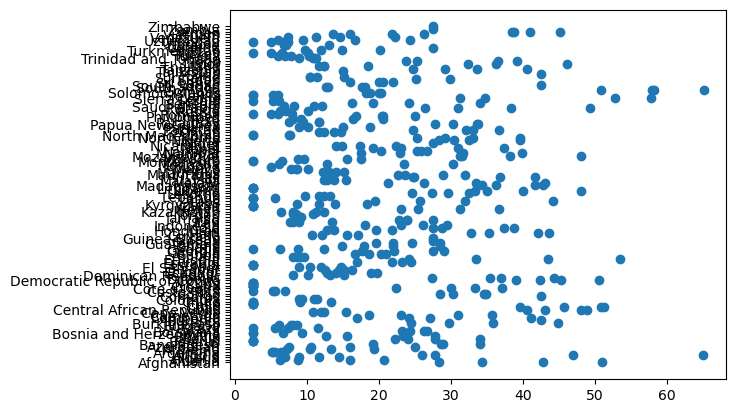

In [17]:
plt.scatter(main_df['Global Hunger Index (2021)'],main_df['Entity'])
plt.show()